In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import json

In [61]:
results_base = Path('results')
if not results_base.exists():
    raise FileNotFoundError(f"Results directory '{results_base}' does not exist.")

timestamped_dirs = [d for d in results_base.iterdir() 
                    if d.is_dir() and len(d.name) == 15 and d.name[8] == '_']

if not timestamped_dirs:
    raise FileNotFoundError("No timestamped result directories found.")

In [62]:
#timestamp = 20251210_123456
timestamp = sorted(timestamped_dirs, key=lambda x: x.name)[-1].name
print(f"Most recent results: {timestamp}")

models_dir = results_base / timestamp
available_models = [d.name for d in models_dir.iterdir() if d.is_dir()]
print(f"\nAvailable models in {timestamp}:")
for model in sorted(available_models):
    print(f"  - {model}")

Most recent results: 20251210_125132

Available models in 20251210_125132:
  - CatBoost
  - LightGBM
  - RandomForest
  - XGBoost


In [63]:
model = "CatBoost"

figures_dir = Path('figures') / timestamp / model
results_dir = Path('results') / timestamp / model

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

In [64]:
results_df = pd.read_csv(results_dir / 'forecast_predictions.csv')
results_df['week_ending'] = pd.to_datetime(results_df['week_ending'])
history_df = pd.read_csv(results_dir / 'training_history.csv')
history_df['week_ending'] = pd.to_datetime(history_df['week_ending'])
print(f"Loaded {len(results_df)} prediction weeks and {len(history_df)} historical weeks.")
results_df['residual'] = results_df['predicted'] - results_df['actual']

Loaded 49 prediction weeks and 126 historical weeks.


In [65]:
metrics_path = results_dir / 'metrics_summary.json'
with open(metrics_path, 'r') as f:
    metrics_summary = json.load(f)
    
print(f"Metrics summary: {metrics_summary}")

Metrics summary: {'overall_mae': 10.857142857142858, 'overall_rmse': 19.944821843459692, 'overall_maape': 20.254130651406957, 'overall_me': -0.4897959183673469}


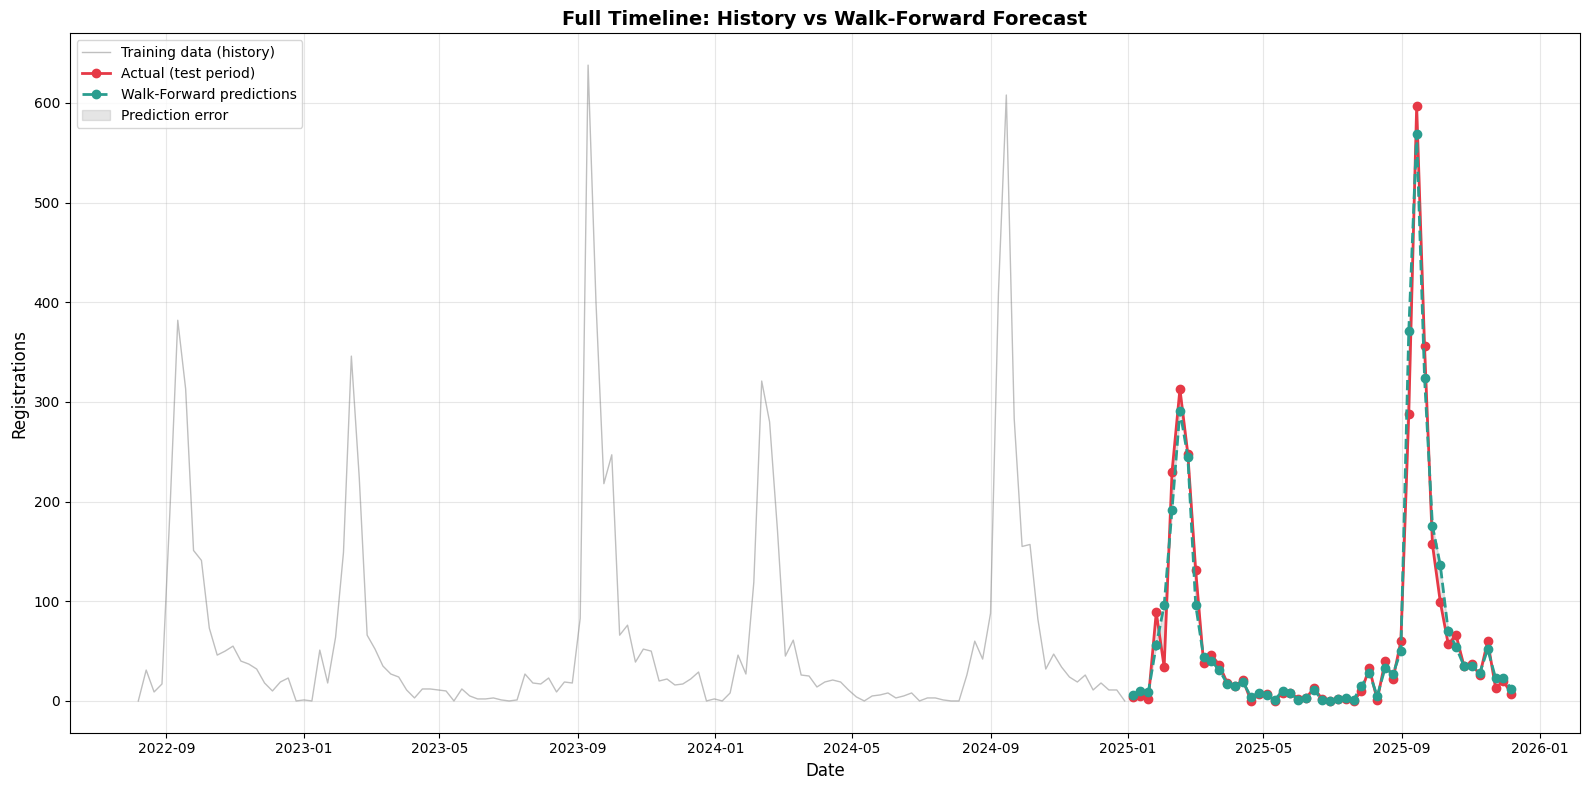

In [66]:
fig, ax = plt.subplots(figsize=(16, 8))

# Plot History
ax.plot(history_df['week_ending'], history_df['registrations'], 
        label='Training data (history)', color='grey', alpha=0.5, linewidth=1)

# Plot Actuals (Test Period)
ax.plot(results_df['week_ending'], results_df['actual'], 
        label='Actual (test period)', color='#E63946', linewidth=2, marker='o', markersize=6)

# Plot Predictions
ax.plot(results_df['week_ending'], results_df['predicted'], 
        label='Walk-Forward predictions', color='#2A9D8F', linewidth=2, 
        linestyle='--', marker='o', markersize=6)

# Fill Error
ax.fill_between(results_df['week_ending'], 
                results_df['actual'], results_df['predicted'],
                alpha=0.2, color='gray', label='Prediction error')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Registrations', fontsize=12)
ax.set_title('Full Timeline: History vs Walk-Forward Forecast', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'full_timeline.png', dpi=300)
plt.show()

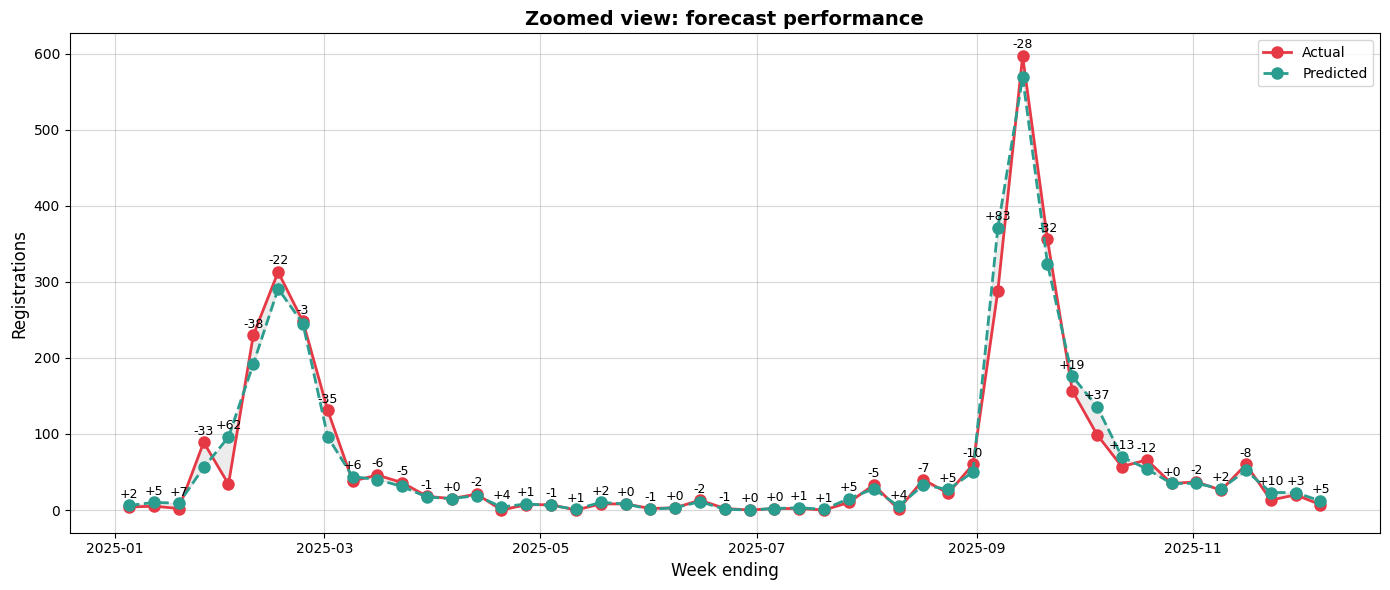

In [67]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(results_df['week_ending'], results_df['actual'], 
        label='Actual', color='#E63946', marker='o', linewidth=2, markersize=8)
ax.plot(results_df['week_ending'], results_df['predicted'], 
        label='Predicted', color='#2A9D8F', linestyle='--', marker='o', linewidth=2, markersize=8)

for _, row in results_df.iterrows():
    ax.annotate(f'{row['residual']:+.0f}', 
                xy=(row['week_ending'], max(row['actual'], row['predicted']) + 10),
                ha='center', fontsize=9, color='black')

ax.fill_between(results_df['week_ending'], 
                results_df['actual'], results_df['predicted'],
                alpha=0.15, color='gray')

ax.set_xlabel('Week ending', fontsize=12)
ax.set_ylabel('Registrations', fontsize=12)
ax.set_title('Zoomed view: forecast performance', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig(figures_dir / 'zoomed_forecast.png', dpi=300)
plt.show()

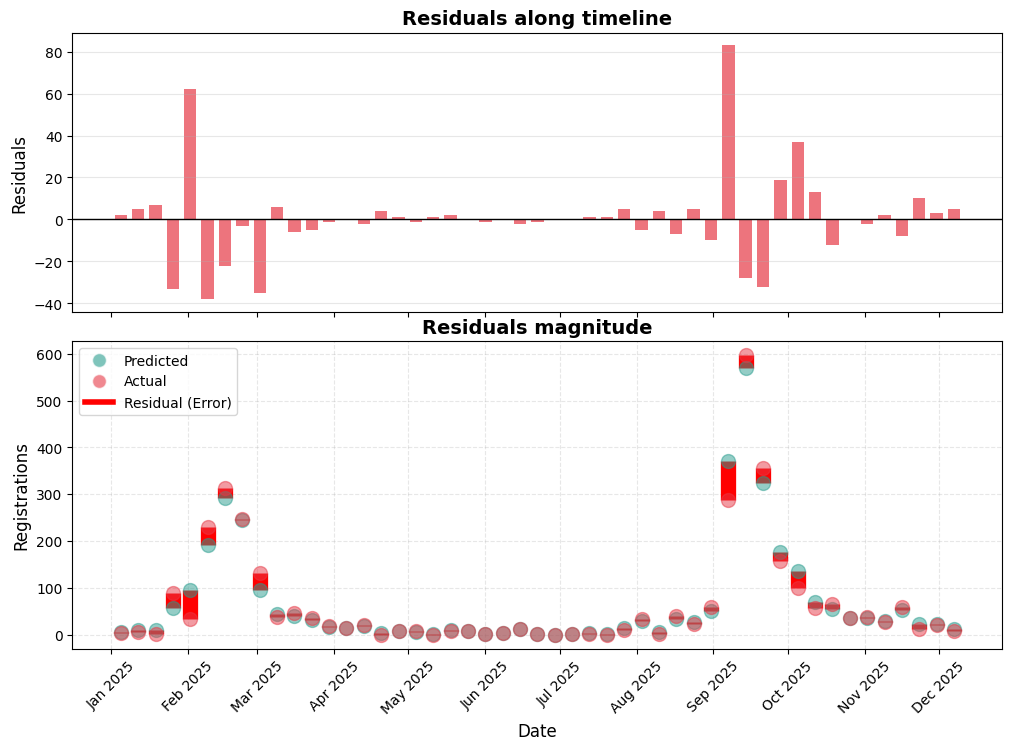

In [68]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [1, 1.1], 'hspace': 0.1})

ax1.bar(results_df['week_ending'], results_df['residual'], color='#E63946', alpha=0.7, width=5)
ax1.axhline(0, color='black', linewidth=1, linestyle='-')

ax1.set_title('Residuals along timeline', fontsize=14, fontweight='bold')
ax1.set_ylabel('Residuals', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

ax2.scatter(results_df['week_ending'], results_df['predicted'], 
            color='#2A9D8F', s=100, zorder=3, label='Predicted Value', alpha=0.5)

for idx, row in results_df.iterrows():
    ax2.vlines(x=row['week_ending'], ymin=row['predicted'], ymax=row['actual'], 
               colors="red", linewidth=11)
    ax2.scatter(row['week_ending'], row['actual'], color='#E63946', s=100, zorder=4, alpha=0.5)

ax2.set_title('Residuals magnitude', fontsize=14, fontweight='bold')
ax2.set_ylabel('Registrations', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Predicted', markerfacecolor='#2A9D8F', markersize=10, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Actual', markerfacecolor='#E63946', markersize=10, alpha=0.6),
    Line2D([0], [0], color='red', lw=4, label='Residual (Error)')    
]
ax2.legend(handles=legend_elements, loc='upper left')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.savefig(figures_dir / 'prediction_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

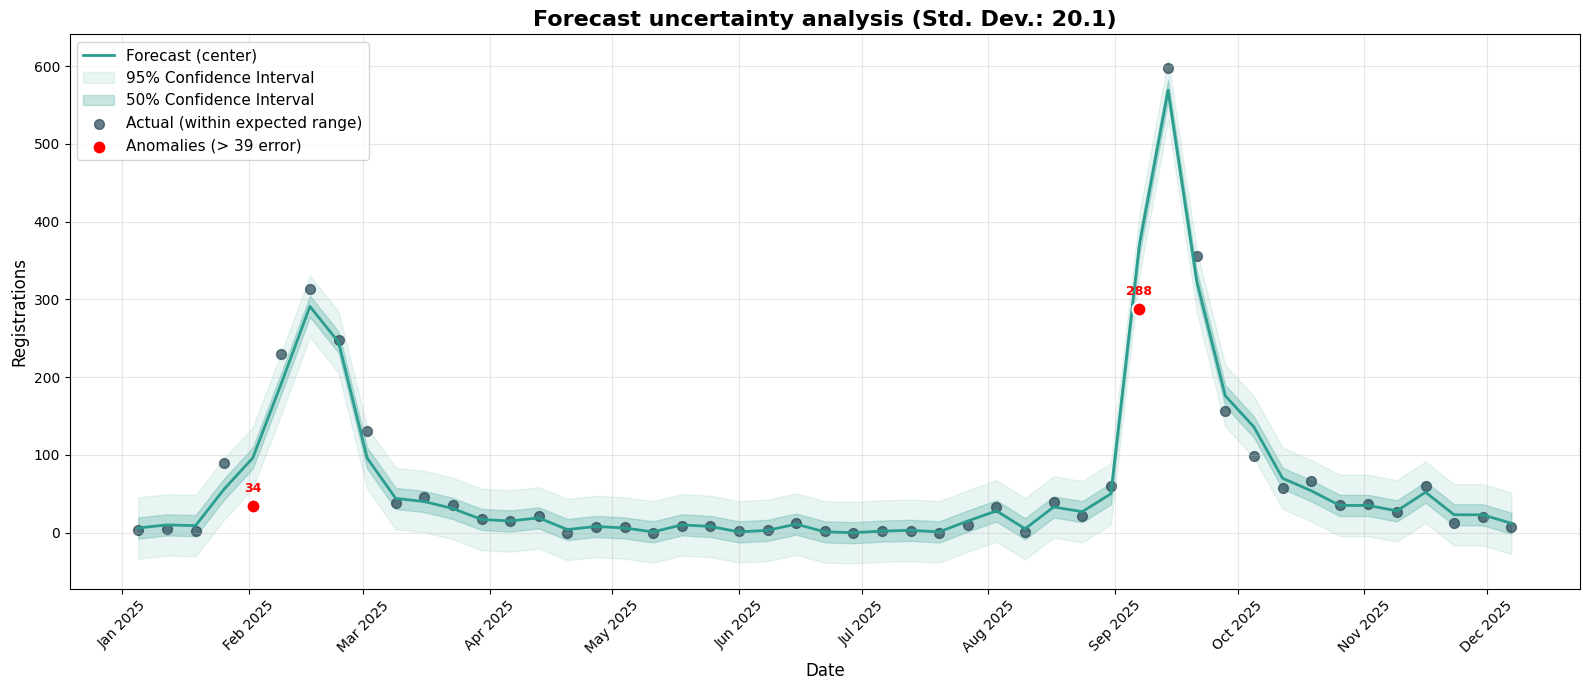

Interval Coverage: 95.9% of actuals fell within the 95% prediction interval.


In [69]:
sigma = results_df['residual'].std()

results_df['upper_95'] = results_df['predicted'] + (1.96 * sigma)
results_df['lower_95'] = results_df['predicted'] - (1.96 * sigma)
results_df['upper_50'] = results_df['predicted'] + (0.675 * sigma)
results_df['lower_50'] = results_df['predicted'] - (0.675 * sigma)

results_df['is_outlier'] = (results_df['actual'] > results_df['upper_95']) | \
                           (results_df['actual'] < results_df['lower_95'])
outliers = results_df[results_df['is_outlier']]
safe_points = results_df[~results_df['is_outlier']]

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(results_df['week_ending'], results_df['predicted'], 
        color='#2A9D8F', linewidth=2, label='Forecast (center)')

ax.fill_between(results_df['week_ending'], 
                results_df['lower_95'], results_df['upper_95'], 
                color='#2A9D8F', alpha=0.10, label='95% Confidence Interval')

ax.fill_between(results_df['week_ending'], 
                results_df['lower_50'], results_df['upper_50'], 
                color='#2A9D8F', alpha=0.25, label='50% Confidence Interval')

ax.scatter(safe_points['week_ending'], safe_points['actual'], 
           color='#264653', s=50, alpha=0.7, label='Actual (within expected range)')

ax.scatter(outliers['week_ending'], outliers['actual'], 
           color='red', s=100, zorder=5, edgecolor='white', linewidth=1.5,
           label=f'Anomalies (> {1.96*sigma:.0f} error)')

for _, row in outliers.iterrows():
    ax.annotate(f"{row['actual']}", 
                xy=(row['week_ending'], row['actual']), 
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='red')

ax.set_title(f'Forecast uncertainty analysis (Std. Dev.: {sigma:.1f})', fontsize=16, fontweight='bold')
ax.set_ylabel('Registrations', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(figures_dir / 'forecast_confidence_intervals.png', dpi=300, bbox_inches='tight')
plt.show()

coverage_95 = (len(results_df) - len(outliers)) / len(results_df) * 100
print(f"Interval Coverage: {coverage_95:.1f}% of actuals fell within the 95% prediction interval.")

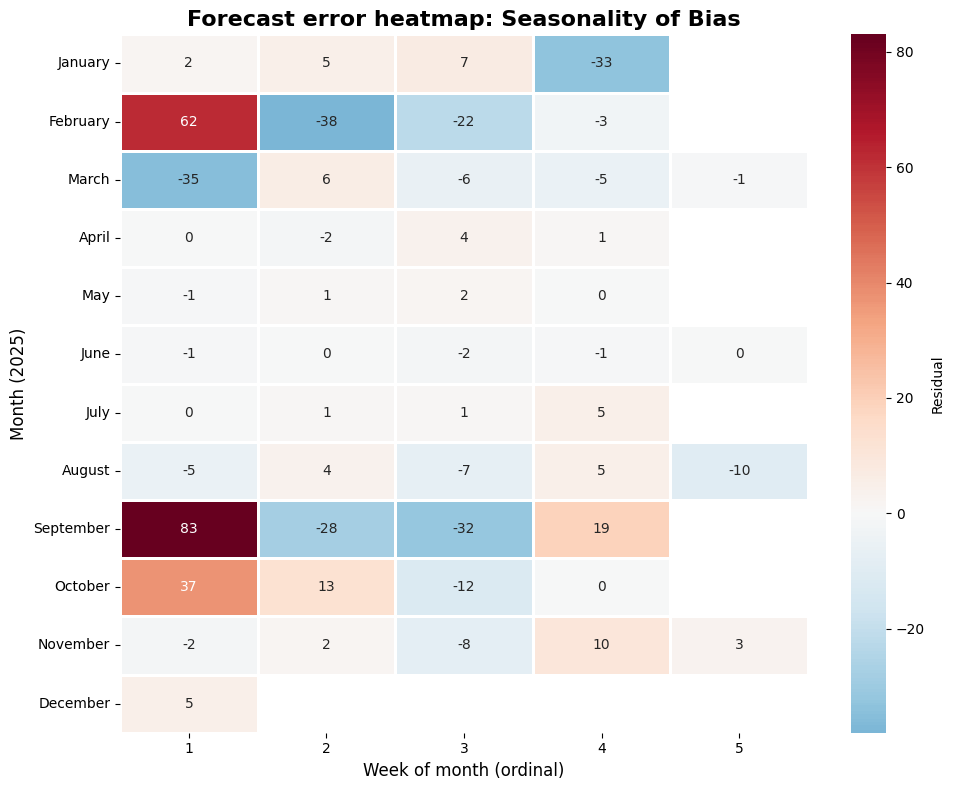

In [70]:
heatmap_df = results_df.copy()
heatmap_df['month_name'] = heatmap_df['week_ending'].dt.strftime('%B')
heatmap_df['month_num'] = heatmap_df['week_ending'].dt.month
heatmap_df['week_of_month'] = heatmap_df['week_ending'].apply(lambda d: (d.day - 1) // 7 + 1)

heatmap_data = heatmap_df.pivot_table(
    index=['month_num', 'month_name'], 
    columns='week_of_month', 
    values='residual',
    aggfunc='mean'
)

heatmap_data.index = heatmap_data.index.get_level_values('month_name')

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(heatmap_data, 
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt='.0f',
            linewidths=1, 
            linecolor='white',
            cbar_kws={'label': 'Residual'},
            ax=ax)

ax.set_title('Forecast error heatmap: Seasonality of Bias', fontsize=16, fontweight='bold')
ax.set_ylabel('Month (2025)', fontsize=12)
ax.set_xlabel('Week of month (ordinal)', fontsize=12)

plt.tight_layout()
plt.savefig(figures_dir / 'error_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

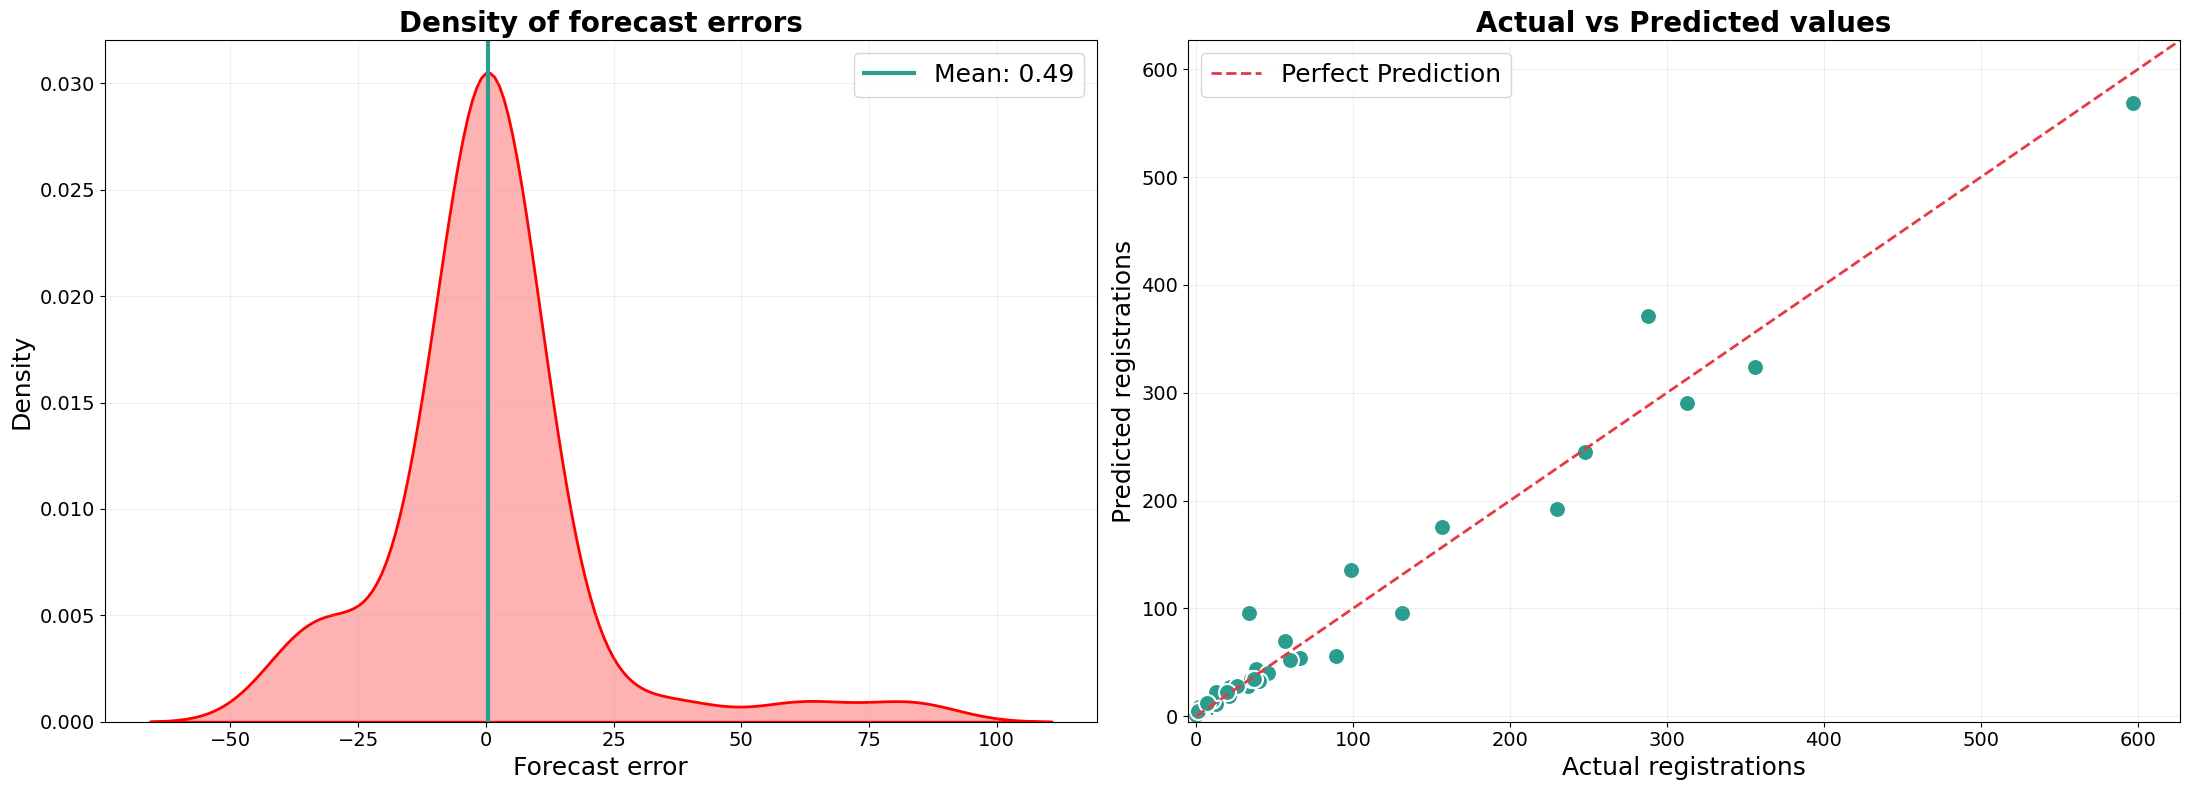

In [71]:
mean_error = results_df['residual'].mean()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.kdeplot(results_df['residual'], ax=axes[0], 
            fill=True,
            color='red',
            alpha=0.3,
            linewidth=2)

axes[0].axvline(mean_error, color='#2A9D8F', linestyle='-', linewidth=3, 
                label=f'Mean: {mean_error:.2f}')

axes[0].set_title('Density of forecast errors', fontsize=20, fontweight='bold')
axes[0].set_xlabel('Forecast error', fontsize=18)
axes[0].set_ylabel('Density', fontsize=18)
axes[0].tick_params(axis='both', which='major', labelsize=14)
axes[0].legend(fontsize=18)
axes[0].grid(True, alpha=0.2)


sns.scatterplot(data=results_df, x='actual', y='predicted', ax=axes[1],
                color='#2A9D8F', s=150, edgecolor='white', linewidth=1.5)

limit = max(results_df['actual'].max(), results_df['predicted'].max()) * 1.05
axes[1].plot([0, limit], [0, limit], color='#e63946', linestyle='--', linewidth=2, label='Perfect Prediction')

axes[1].set_title('Actual vs Predicted values', fontsize=20, fontweight='bold')
axes[1].set_xlabel('Actual registrations', fontsize=18)
axes[1].set_ylabel('Predicted registrations', fontsize=18)
axes[1].tick_params(axis='both', which='major', labelsize=14)
axes[1].set_xlim(-5, limit)
axes[1].set_ylim(-5, limit)
axes[1].legend(loc='upper left', fontsize=18)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(figures_dir / 'error_density.png', dpi=300)
plt.show()

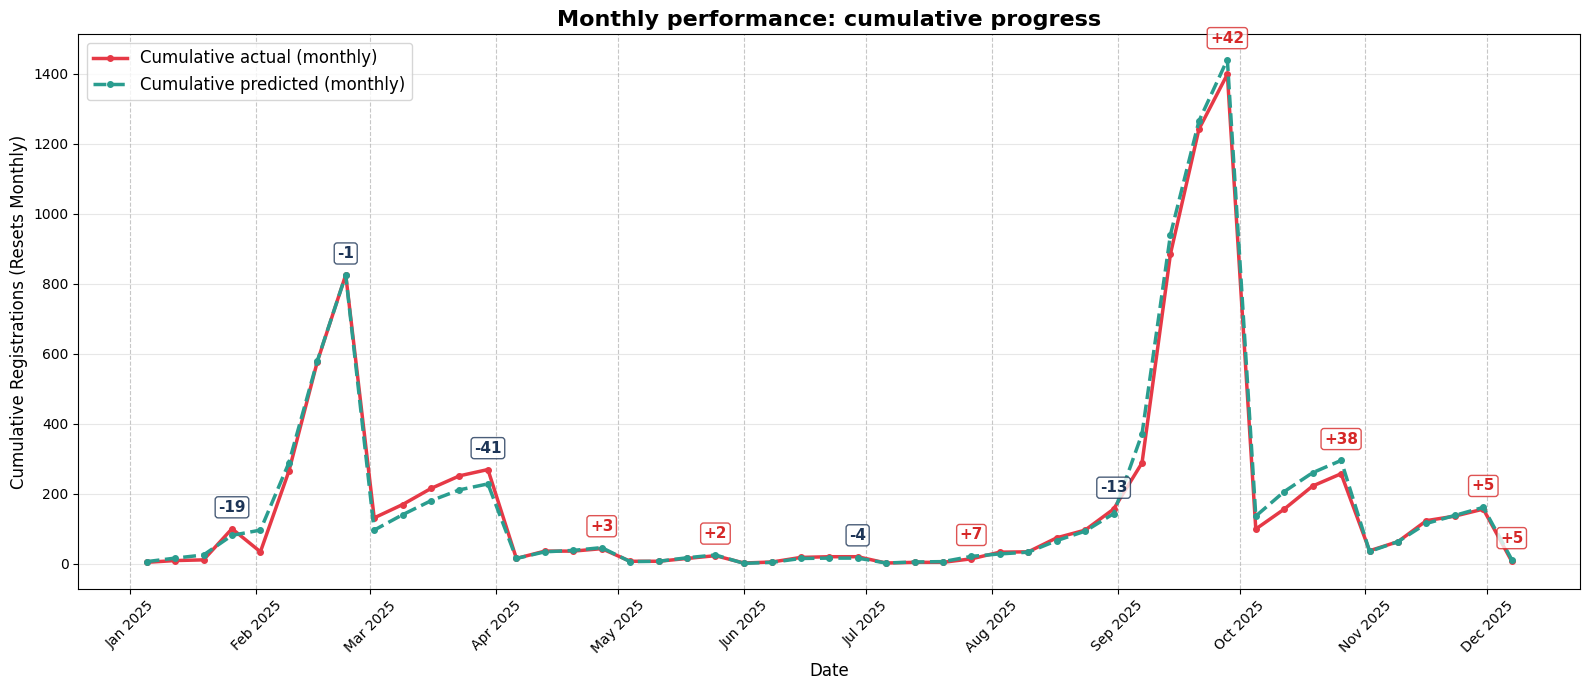

In [72]:
results_df['month_period'] = results_df['week_ending'].dt.to_period('M')

results_df['month_cum_actual'] = results_df.groupby('month_period')['actual'].cumsum()
results_df['month_cum_pred'] = results_df.groupby('month_period')['predicted'].cumsum()

monthly_stats = results_df.groupby('month_period').agg({
    'week_ending': 'max',
    'month_cum_actual': 'max',
    'month_cum_pred': 'max',
    'actual': 'sum',
    'predicted': 'sum'
}).reset_index()

monthly_stats['diff'] = monthly_stats['predicted'] - monthly_stats['actual']

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(results_df['week_ending'], results_df['month_cum_actual'], 
        label='Cumulative actual (monthly)', color='#E63946', linewidth=2.5, marker='o', markersize=4)

ax.plot(results_df['week_ending'], results_df['month_cum_pred'], 
        label='Cumulative predicted (monthly)', color='#2A9D8F', 
        linestyle='--', linewidth=2.5, marker='o', markersize=4)

for _, row in monthly_stats.iterrows():
    diff = row['diff']
    color = '#d62828' if diff > 0 else '#1d3557'
    sign = '+' if diff > 0 else ''
    
    max_height = max(row['month_cum_actual'], row['month_cum_pred'])
    
    ax.annotate(f"{sign}{diff:.0f}", 
                xy=(row['week_ending'], max_height), 
                xytext=(0, 10),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=color,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.8))

ax.set_title('Monthly performance: cumulative progress', fontsize=16, fontweight='bold')
ax.set_ylabel('Cumulative Registrations (Resets Monthly)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.7)
ax.grid(True, which='major', axis='y', alpha=0.3)

plt.xticks(rotation=45)
plt.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig(figures_dir / 'monthly_cumulative_performance.png', dpi=300, bbox_inches='tight')
plt.show()

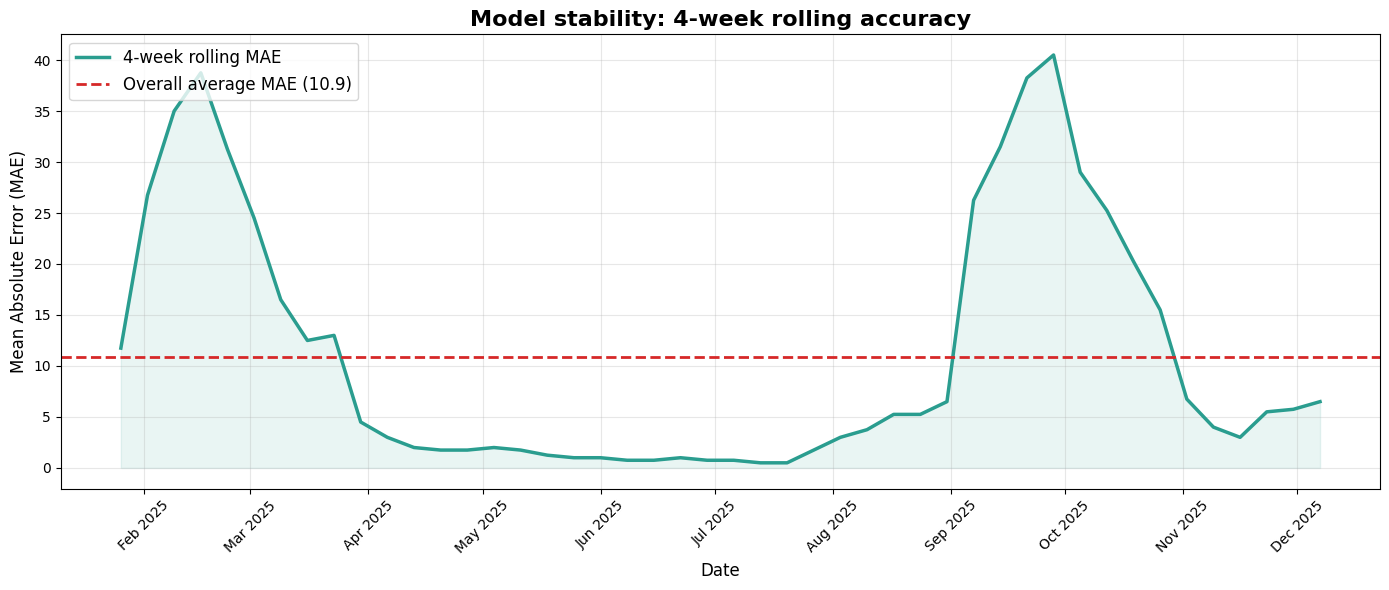

In [73]:
window_size = 4
results_df['rolling_mae'] = results_df['residual'].abs().rolling(window=window_size).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(results_df['week_ending'], results_df['rolling_mae'], 
        color='#2A9D8F', linewidth=2.5, label=f'{window_size}-week rolling MAE')

overall_mae = results_df['residual'].abs().mean()
ax.axhline(overall_mae, color='#d62828', linestyle='--', linewidth=2, 
           label=f'Overall average MAE ({overall_mae:.1f})')

ax.fill_between(results_df['week_ending'], results_df['rolling_mae'], 
                color='#2A9D8F', alpha=0.1)

ax.set_title(f'Model stability: {window_size}-week rolling accuracy', fontsize=16, fontweight='bold')
ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(figures_dir / 'rolling_stability.png', dpi=300, bbox_inches='tight')
plt.show()